# Лабораторная работа №1
## Сжатие изображений с помощью SVD

**Выполнил:** Чубаев Кирилл Евгеньевич  
**Группа:** НПМбд-01-24  
**Преподаватель:** Карандашев Я. М.


## 1. Цель работы
Целью данной лабораторной работы является научиться сжимать изображения с помощью SVD и выяснить, как количество оставленных
компонент влияет на качество картинки и объём хранимых данных.

## 2. Выполнение заданий
### Часть А. Загрузка и подготовка изображения



Размер цветного изображения: (300, 451, 3)
Размер массива в градациях серого: (300, 451)
Тип пикселей: uint8


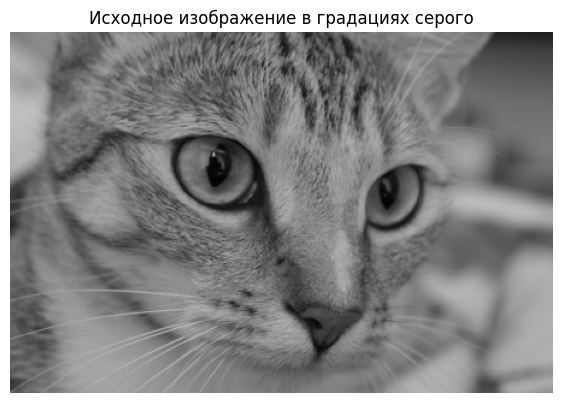

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from urllib.request import urlopen
from io import BytesIO
from pathlib import Path

folder = Path('svd_cat_results')
folder.mkdir(exist_ok=True)
url = 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/chelsea.png'
with urlopen(url, timeout=30) as response:
    image_data = response.read()

img = Image.open(BytesIO(image_data)).convert('RGB')
assert img.width >= 300 and img.height >= 300
gray = img.convert('L')
original = np.array(gray)
original_shape = original.shape
h, w = original_shape
A = original.astype(np.float64)
original_flat = A.flatten()
gray.save(folder / 'original_gray.png')

print('Размер цветного изображения:', np.array(img).shape)
print('Размер массива в градациях серого:', original_shape)
print('Тип пикселей:', original.dtype)
plt.figure(figsize=(7, 5))
plt.imshow(original, cmap='gray', vmin=0, vmax=255)
plt.title('Исходное изображение в градациях серого')
plt.axis('off')
plt.show()


**Результат части А:** Я получил одну матрицу размером 300×451 вместо трёх цветовых каналов.
Каждое число в ней задаёт яркость пикселя: 0 — чёрный, 255 — белый.
Далее я сравнивал восстановленные картинки именно с этим изображением в градациях серого.


### Часть Б. SVD и восстановление
Я разложил матрицу с помощью `np.linalg.svd` и оставил разное количество компонент.
Ранг `r` здесь означает, сколько компонент я использую для восстановления.


In [2]:
U, s, Vt = np.linalg.svd(A, full_matrices=False)
list_of_ranks = [1, 5, 10, 30, 100, min(original_shape)]
approximations = []
raw_errors = []

for r in list_of_ranks:
    restored = (U[:, :r] * s[:r]) @ Vt[:r, :]
    raw_errors.append(np.mean((A - restored) ** 2))
    # Ограничиваем яркость и округляем до целых значений.
    restored = np.rint(np.clip(restored, 0, 255)).astype(np.uint8)
    approximations.append(restored)

print('Использованные ранги:', list_of_ranks)
print('Размеры U, s и Vt:', U.shape, s.shape, Vt.shape)
print('При полном ранге пиксели совпадают:', np.array_equal(original, approximations[-1]))


Использованные ранги: [1, 5, 10, 30, 100, 300]
Размеры U, s и Vt: (300, 300) (300,) (300, 451)
При полном ранге пиксели совпадают: True


**Результат части Б:** Я восстановил изображение для рангов 1, 5, 10, 30, 100 и 300.
SVD вычислил один раз, а затем использовал нужное количество компонент.
При полном ранге 300 после округления получилось исходное изображение без изменений пикселей.


### Часть В. Сравнение изображений
Я вывел все шесть вариантов на одном графике. Для подписей посчитал сжатие с учётом того,
что исходный пиксель занимает 1 байт, а сохранённое число `float32` — 4 байта.


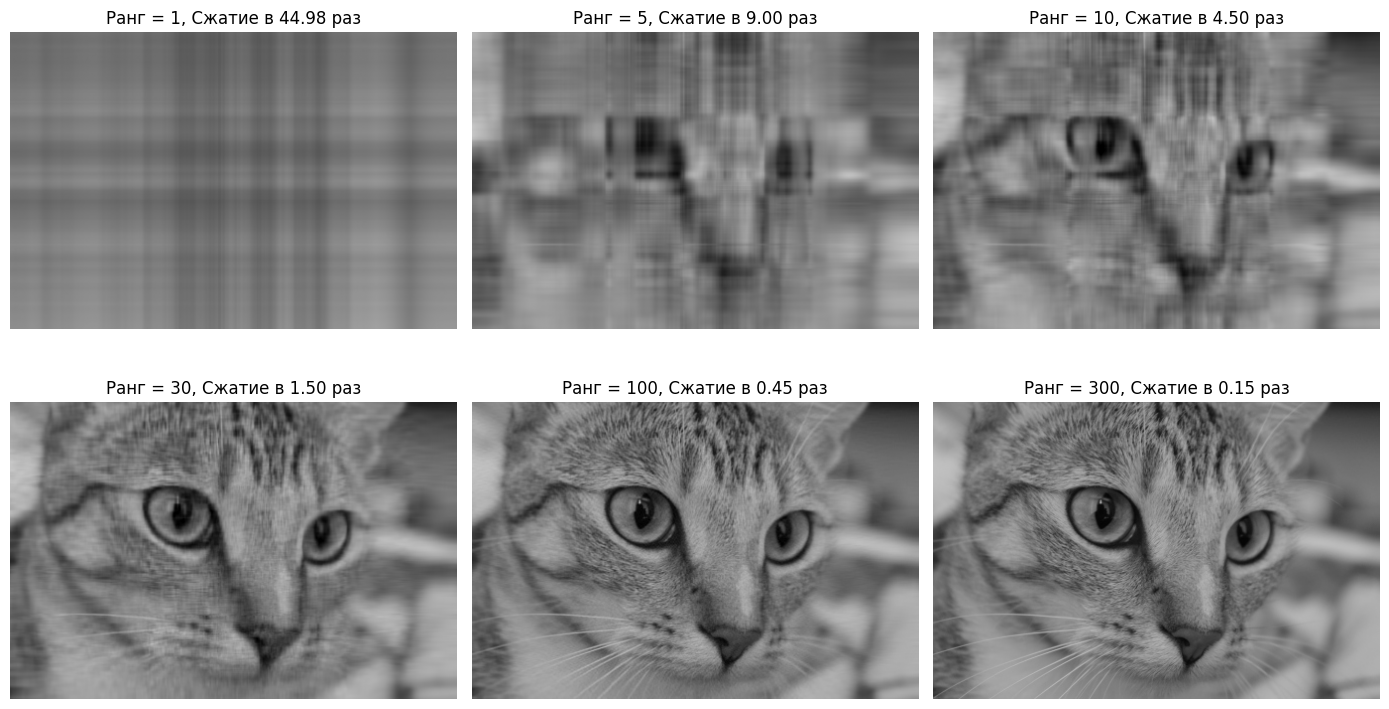

In [3]:
original_bytes = original.nbytes
compressed_sizes = [4 * r * (h + w + 1) for r in list_of_ranks]
ratios = [original_bytes / size for size in compressed_sizes]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(approximations[i], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Ранг = {list_of_ranks[i]}, Сжатие в {ratios[i]:.2f} раз')
    ax.axis('off')
plt.tight_layout()
plt.savefig(folder / 'comparison.png')
plt.show()


**Результат части В:** При ранге 1 почти нет деталей. При 5 и 10 уже видно кота,
но изображение размыто. При 30 деталей становится больше, а при 100 картинка выглядит
близко к оригиналу. При ранге 300 она совпадает с исходной.
Число меньше 1 в подписи означает, что данные занимают больше места, чем исходный массив.


### Часть Г. Размер данных и качество
Я сравнил объём исходной матрицы с объёмом трёх частей SVD.
Так как изображение серое, умножать размер на три канала не нужно.

- Исходная матрица: $h\cdot w$ байт.
- Части SVD: $4r(h+w+1)$ байт при хранении в `float32`.
- Коэффициент сжатия: $K=\dfrac{hw}{4r(h+w+1)}$.

Также я сохранил части SVD в NPZ и восстановленные картинки в PNG, чтобы посмотреть
на настоящие размеры файлов. У NPZ есть небольшие служебные данные.
PNG хранит пиксели своим способом, поэтому его размер не равен размеру частей SVD.
MSE показывает среднюю ошибку по пикселям: чем она меньше, тем точнее результат.


Исходная матрица: 135300 байт
Исходный серый PNG: 80400 байт
 Ранг    SVD, байт    Сжатие        MSE    NPZ, байт    PNG, байт
    1         3008     44.98     847.99         3734        26625
    5        15040      9.00     339.04        15766        40899
   10        30080      4.50     178.91        30806        48109
   30        90240      1.50      52.81        90966        62124
  100       300800      0.45       7.06       301526        75999
  300       902400      0.15       0.00       903126        77779
Наибольший ранг для сжатия хотя бы в 10 раз: 4
Сжатие при этом ранге: 11.25


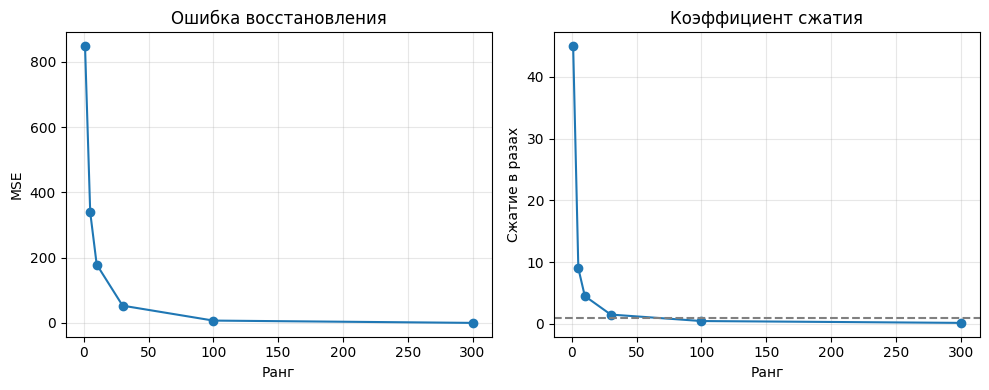

In [4]:
errors = []
print('Исходная матрица:', original_bytes, 'байт')
print('Исходный серый PNG:', (folder / 'original_gray.png').stat().st_size, 'байт')
print(f'{"Ранг":>5} {"SVD, байт":>12} {"Сжатие":>9} {"MSE":>10} {"NPZ, байт":>12} {"PNG, байт":>12}')

for i, r in enumerate(list_of_ranks):
    error = np.mean((A - approximations[i].astype(np.float64)) ** 2)
    errors.append(error)
    npz_path = folder / f'svd_{r}.npz'
    png_path = folder / f'cat_{r}.png'
    np.savez(npz_path, U=U[:, :r].astype(np.float32),
             s=s[:r].astype(np.float32), Vt=Vt[:r, :].astype(np.float32))
    Image.fromarray(approximations[i]).save(png_path)
    print(f'{r:5d} {compressed_sizes[i]:12d} {ratios[i]:9.2f} {error:10.2f}'
          f' {npz_path.stat().st_size:12d} {png_path.stat().st_size:12d}')

r_10 = int(h * w // (40 * (h + w + 1)))
print('Наибольший ранг для сжатия хотя бы в 10 раз:', r_10)
print('Сжатие при этом ранге:', round(original_bytes / (4 * r_10 * (h + w + 1)), 2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list_of_ranks, errors, 'o-')
axes[0].set_title('Ошибка восстановления')
axes[0].set_ylabel('MSE')
axes[1].plot(list_of_ranks, ratios, 'o-')
axes[1].axhline(1, color='gray', linestyle='--')
axes[1].set_title('Коэффициент сжатия')
axes[1].set_ylabel('Сжатие в разах')
for ax in axes:
    ax.set_xlabel('Ранг')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Результат части Г:** Я сравнил размеры и увидел, что увеличение ранга улучшает картинку,
но увеличивает объём данных. Для этого изображения исходная матрица занимает 135 300 байт.
При ранге 30 части SVD занимают 90 240 байт: сжатие примерно в 1,50 раза.
При ранге 100 они уже занимают 300 800 байт — больше исходной матрицы.
При полном ранге размер ещё больше, поэтому для экономии места он не подходит.


### Ошибка на тёмных и светлых участках
Я отдельно посчитал ошибку в тёмных и светлых пикселях при ранге 30.


In [5]:
image_30 = approximations[list_of_ranks.index(30)].astype(np.float64)
pixel_errors = (A - image_30) ** 2
dark = original < 128
light = original >= 128
print('MSE на тёмных участках:', round(pixel_errors[dark].mean(), 2))
print('MSE на светлых участках:', round(pixel_errors[light].mean(), 2))


MSE на тёмных участках: 59.23
MSE на светлых участках: 44.14


## 3. Автоматическая проверка

In [6]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")


✅ Все автоматические проверки пройдены. Задание выполнено корректно!


## 4. Ответы на вопросы

**При каком ранге визуальное качество перестаёт отличаться от оригинала?**  
На общем графике при ранге 100 я вижу картинку, уже близкую к оригиналу.
Но небольшие отличия ещё могут быть заметны при увеличении.
Из проверенных вариантов точно такое же изображение получилось при ранге 300:
его пиксели совпали с исходными.

**Для какого ранга достигается сжатие в 10 раз?**  
Я посчитал, что для моей картинки нужно взять ранг не больше 4.
При ранге 4 получается сжатие примерно в 11,25 раза, а при ранге 5 — только в 9 раз.
Ровно 10 раз здесь не получается, потому что ранг должен быть целым числом.
Из заданного списка сжатие не меньше чем в 10 раз даёт только ранг 1.
Здесь я сравниваю размер частей SVD с размером исходного массива, а не PNG-файла.

**Почему для тёмных и светлых участков ошибка разная?**  
При сжатии теряются мелкие детали, например шерсть и границы предметов.
Гладкие участки восстановить легче, а участки с большим количеством деталей — сложнее.
Тёмные и светлые части фотографии содержат разные детали, поэтому ошибка в них отличается.
Я посчитал её отдельно для двух групп пикселей выше. Нельзя сказать, что тёмные участки
всегда восстанавливаются хуже светлых: это зависит от самой картинки.

## 5. Выводы
В ходе выполнения данной лабораторной работы я перевёл фотографию в градации серого и применил SVD. Также
я восстановил картинку для шести рангов и сравнил качество и размер данных.
Я увидел, что при маленьком ранге данные занимают мало места, но теряются детали.
С увеличением ранга изображение становится точнее, однако размер частей SVD растёт.
При ранге 30 удалось немного уменьшить объём данных, сохранив узнаваемую картинку.
Для сжатия хотя бы в 10 раз нужен ранг не больше 4, но качество при этом заметно ухудшается.
Полный ранг восстанавливает все пиксели, однако не даёт экономии памяти.
Все автоматические проверки прошли успешно.
